GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/juseppe/miniconda3/envs/flwr-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=0` reached.
saving figure to file figures/umapfinal_umap.png


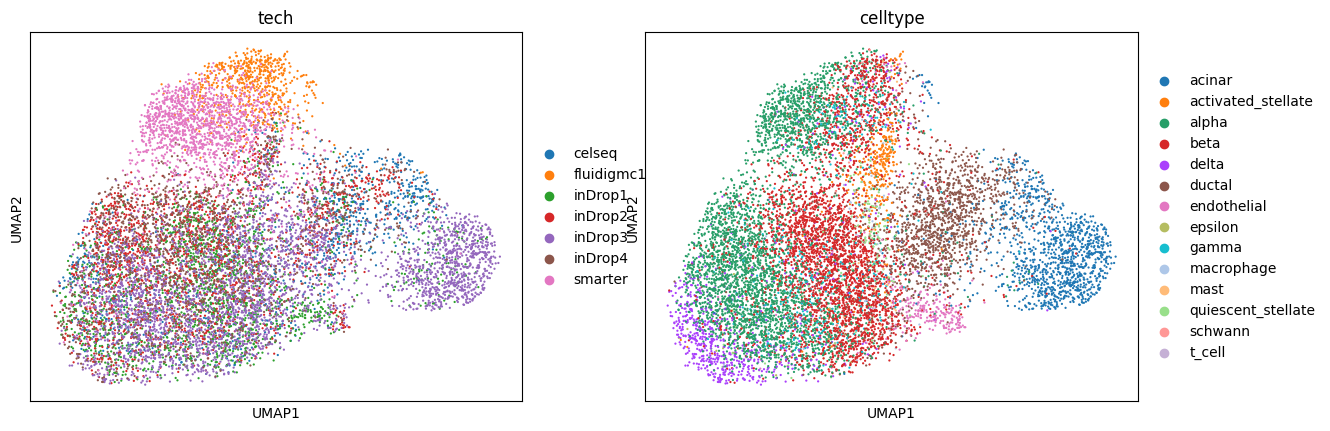

In [11]:
import torch
import anndata
from federated_scvi_flower.model_utils_scvi import get_scvi_model, set_weights, plot_latent_umap

# Load AnnData
adata = anndata.read_h5ad("federated_scvi_flower/final_server_model_adata.h5ad")

# Rebuild model and load weights
model = get_scvi_model(adata)
state_dict = torch.load("federated_scvi_flower/final_server_model.pt")
model.module.load_state_dict(state_dict, strict=True)
model.train(max_epochs=0)  # Mark as trained

# Get latent and plot
adata.obsm["X_scVI"] = model.get_latent_representation()
plot_path = "final_umap.png"
plot_latent_umap(adata, color=["tech", "celltype"], save=plot_path)